In this notebook, we demonstrate the application of 4D-Var on the 1D KdV system, where the dynamical core is imported from a JAX solver exponax[1]. We bridge the gradient propagation between adda which is written in torch and exponax which is written in JAX. Python 3.10, exponax and jax are necessary to run this notebook.

[1] https://github.com/Ceyron/exponax

KdV system:

$$ \frac{\partial u}{\partial t} - \frac{6}{2} \frac{\partial u^2}{\partial x} + \frac{\partial^3 u}{\partial x^3} = - 0.01 \frac{\partial^4 u}{\partial x^4} $$



In [1]:
import os
import torch
import jax
from matplotlib import pyplot as plt
from tensordict import TensorDict
from time import time
import exponax as ex
import exponax.stepper as st
os.chdir('..')
from adda.convert.jax import jax_to_torch_fn, t2j, j2t
from adda.variational.strong_constraint_4dvar import sc4dvar_single_window
from adda.variational.weak_constraint_4dvar import wc4dvar_single_window
from adda.system.state import State
from adda.util.visualization import show_1dseqimg
from adda.observation.operators import random_sparse_noisy_obs
from adda.util.initialization import naive_initialization
from adda.probability.distributions import DiagonalGaussian

# Generation of groundtruth data

In [2]:
torch.backends.cudnn.deterministic = True
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Experiment parameters
DOMAIN_EXTENT = 30.0
NUM_POINTS = 400
DT = 0.01
kdv_stepper = ex.stepper.KortewegDeVries(1, DOMAIN_EXTENT, NUM_POINTS, DT)
tot_timesteps = 999

In [3]:
# We create the jax solver and wrap a torch class around it for gradient propagation
forward_operator_torch = jax_to_torch_fn(jax.jit(ex.rollout(kdv_stepper, tot_timesteps, include_init=True)))
forward_assimilate = jax_to_torch_fn(jax.jit(ex.rollout(kdv_stepper, 1, include_init=True)))

In [4]:
mesh = torch.linspace(0.0, DOMAIN_EXTENT, NUM_POINTS+1)[:-1]
initial_state = torch.cos(4 * torch.pi * mesh / DOMAIN_EXTENT)
initial_state = initial_state.unsqueeze(0)
initial_state = initial_state.to(device)
print("Initial Condition Shape: ", initial_state.shape)
forecast_steps = torch.arange(0, tot_timesteps * DT, DT)
kdv_series = forward_operator_torch(initial_state).squeeze()
print("Complete Series Shape: ", kdv_series.shape)

Initial Condition Shape:  torch.Size([1, 400])
Complete Series Shape:  torch.Size([1000, 400])


torch.Size([1000, 400])


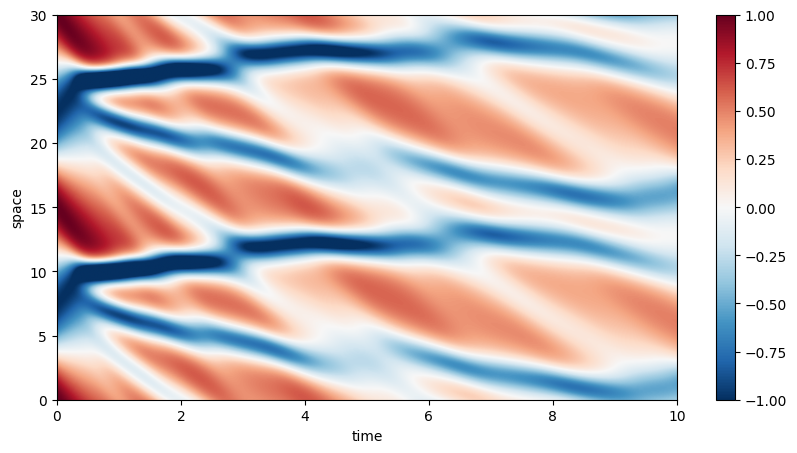

In [5]:
kdv_series = kdv_series
ctrj = kdv_series.cpu().numpy()
plt.figure(figsize=(10, 5))
plt.imshow(
    ctrj.transpose(),
    cmap="RdBu_r",
    aspect="auto",
    origin="lower",
    extent=(0, ctrj.shape[0] * DT, 0, DOMAIN_EXTENT),
    vmin=-1, vmax=1
)
plt.colorbar()
plt.xlabel("time")
plt.ylabel("space")
print(kdv_series.shape)

In [6]:
tot_timesteps = kdv_series.shape[0]
true_initial_state = kdv_series[0]
forecast_steps = torch.arange(0, tot_timesteps * DT, DT)
true_series = State(kdv_series.reshape(1, -1, NUM_POINTS), time_axis=forecast_steps)
print("Shape of the Ground Truth Series: ", true_series.shape)

Shape of the Ground Truth Series:  {'x': torch.Size([1, 1000, 400])}


Text(0.5, 1.0, 'Initial Ground Truth State of the KdV System')

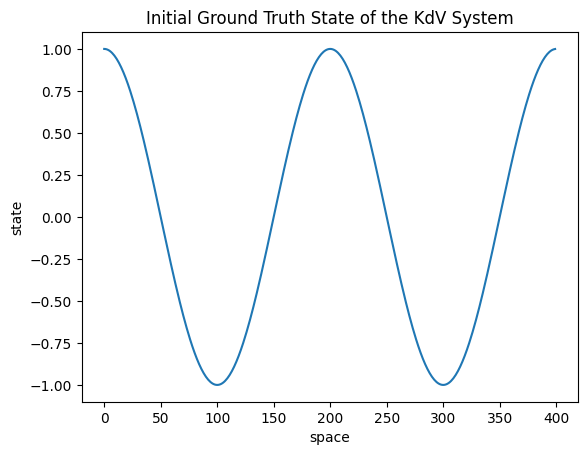

In [7]:
plt.plot(true_initial_state.cpu())
plt.xlabel("space")
plt.ylabel("state")
plt.title("Initial Ground Truth State of the KdV System")

In [8]:
# In order to use the 4D-Var function, you should always have a function like this taking the state, dt, dynamic_inputs and static_inputs
def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    B, T = x.fields.batch_size[:2]
    input = x.fields["x"].reshape(B * T, NUM_POINTS)
    integrated = forward_assimilate(input)[-2:-1].unsqueeze(0).T # integrate over a time step, take the current time
    integrated = integrated.reshape(B, T, NUM_POINTS)
    new_fields = TensorDict(x=integrated, batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + DT)  # return State object, advancing time

# Strong-constraint 4D-var

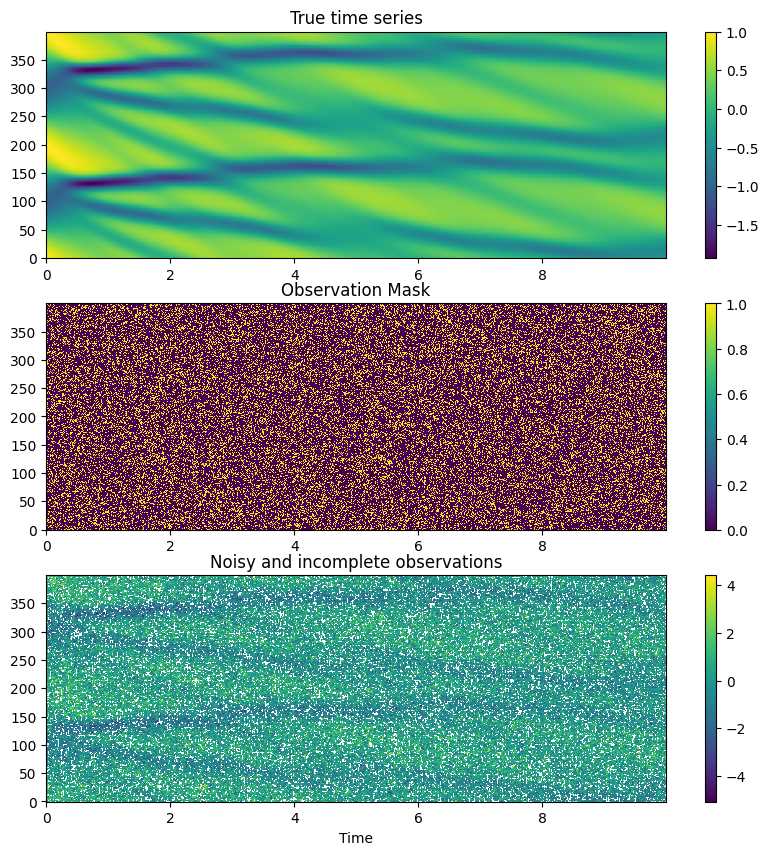

In [9]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.25 # 75% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_series, noise_amplitude, p_obs)

valid_obs = observations.state.fields['x'][0].T
valid_obs[torch.logical_not(observations.mask.fields['x'][0].T)] = torch.nan
fig, ax = plt.subplots(3, 1, figsize=(10,10))

show_1dseqimg(true_series.fields['x'][0].T.detach().cpu().numpy(), dt=DT, ax=ax[0], title="True time series")
show_1dseqimg(observations.mask.fields['x'][0].T.detach().cpu().numpy(), dt=DT, ax=ax[1], title="Observation Mask")
show_1dseqimg(valid_obs.detach().cpu().numpy(), dt=DT, ax=ax[2], title="Noisy and incomplete observations", x_label="Time")

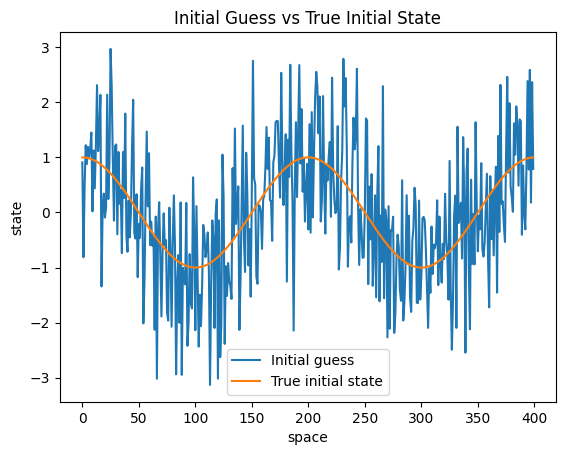

In [10]:
initialization = naive_initialization(observations)  # state estimate for all time points
initialization = initialization[:, :1]  # first time point only

plt.plot(initialization.fields['x'].squeeze().detach().cpu().numpy(), label='Initial guess')
plt.plot(true_series.fields['x'].squeeze()[0].detach().cpu().numpy(), label='True initial state')
plt.legend()
plt.title("Initial Guess vs True Initial State")
plt.xlabel("space")
plt.ylabel("state")
plt.show()

In [11]:
n_obs_steps = 50 # Time steps to assimilate.
time_window = (observations.state.time_axis[0], observations.state.time_axis[n_obs_steps])

obs_op_opt = obs_op.restrict_time_domain(*time_window)
observations_opt = observations.restrict_time_domain(*time_window)

In [12]:
t0 = time()
assimilated_ic = sc4dvar_single_window(next_step_function, 
                                       observations_opt, 
                                       obs_op_opt, 
                                       initialization,                                        
                                       optimizer_pars={'lr': 1e-1},
                                       verbose=1,
                                       n_steps=5)                                     
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

C:\Users\Frion\AppData\Local\Temp\ipykernel_10992\468037726.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3729.)
  integrated = forward_assimilate(input)[-2:-1].unsqueeze(0).T # integrate over a time step, take the current time


iteration 0: loss = 9597.5703125
iteration 0: loss = 9594.3046875
iteration 0: loss = 8675.6767578125
iteration 0: loss = 7927.15576171875
iteration 0: loss = 7320.45068359375
iteration 0: loss = 6828.9970703125
iteration 0: loss = 6430.9248046875
iteration 0: loss = 6108.4921875
iteration 0: loss = 5847.32275390625
iteration 0: loss = 5635.77685546875
iteration 0: loss = 5464.4248046875
iteration 0: loss = 5325.6298828125
iteration 0: loss = 5213.20556640625
iteration 0: loss = 5122.142578125
iteration 0: loss = 5048.380859375
iteration 0: loss = 4988.6337890625
iteration 0: loss = 4940.2392578125
iteration 0: loss = 4901.0390625
iteration 0: loss = 4869.28662109375
iteration 0: loss = 4843.56787109375
iteration 1: loss = 4822.73583984375
iteration 1: loss = 4805.861328125
iteration 1: loss = 4792.19287109375
iteration 1: loss = 4781.12158203125
iteration 1: loss = 4772.15380859375
iteration 1: loss = 4764.89013671875
iteration 1: loss = 4759.0068359375
iteration 1: loss = 4754.240722

In [13]:
# We generate the trajectories from the assimilated initial condition and the initial guess to see how they compare with the true trajectory.
assim_input = assimilated_ic.fields['x'].reshape(1, NUM_POINTS)
initialization_input = initialization.fields['x'].reshape(1, NUM_POINTS)
assimilated_trajectory = forward_operator_torch(assim_input).squeeze()
print("Shape of the Assimilated Trajectory: ", assimilated_trajectory.shape)
trajectories_from_initial_guess = forward_operator_torch(initialization_input).squeeze()
print("Shape of the Trajectory from the Initial Guess: ", trajectories_from_initial_guess.shape)
error = assimilated_trajectory.detach() - true_series.fields['x']
error_2 = trajectories_from_initial_guess.detach() - true_series.fields['x']
err_max = max(error.max(), error_2.max())
err_min = min(error.min(), error_2.min())

Shape of the Assimilated Trajectory:  torch.Size([1000, 400])
Shape of the Trajectory from the Initial Guess:  torch.Size([1000, 400])


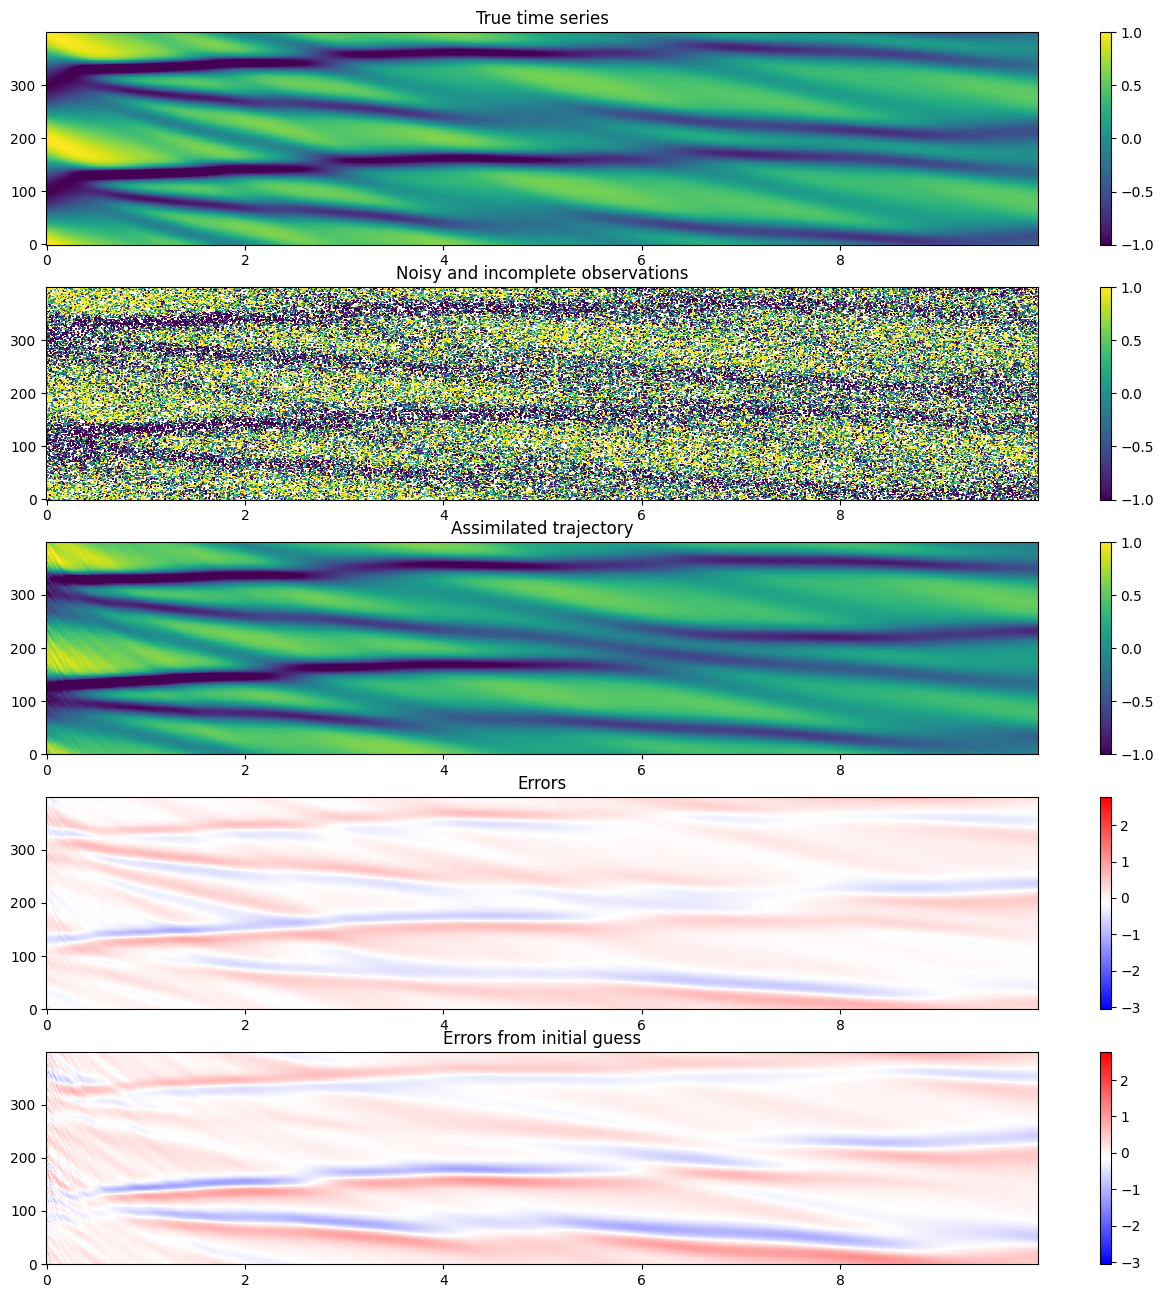

In [14]:
# We visualize the errors of the assimilated trajectory and the trajectory from the initial guess.
fig, ax = plt.subplots(5, 1, figsize=(16,16))
show_1dseqimg(true_series.fields['x'][0].T.detach().cpu().numpy(), dt=DT, ax=ax[0], vmin=-1, vmax=1, title="True time series")
show_1dseqimg(valid_obs.detach().cpu().numpy(), dt=DT, ax=ax[1], vmin=-1, vmax=1, title="Noisy and incomplete observations")
show_1dseqimg(assimilated_trajectory.detach().T.detach().cpu().numpy(), dt=DT, ax=ax[2], vmin=-1, vmax=1, title="Assimilated trajectory")
show_1dseqimg(error.detach().squeeze().T.detach().cpu().numpy(), dt=DT, ax=ax[3], title="Errors", cmap="bwr", vmin=err_min, vmax=err_max)
show_1dseqimg(error_2.detach().squeeze().T.detach().cpu().numpy(), dt=DT, ax=ax[4], title="Errors from initial guess", cmap="bwr", vmin=err_min, vmax=err_max)

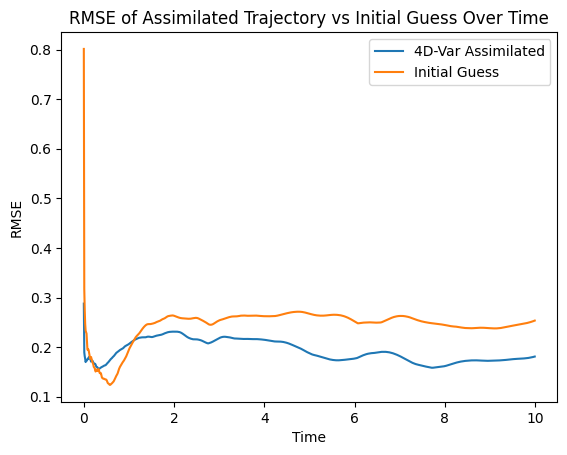

In [15]:
# We can also plot the RMSE of the assimilated trajectory and the trajectory from the initial guess over time.
RMSE_over_time_assimilated = torch.mean(torch.sqrt((error.squeeze().T ** 2)), dim=0)
RMSE_over_time_initial = torch.mean(torch.sqrt((error_2.squeeze().T ** 2)), dim=0)

fig, ax = plt.subplots()
plt.plot(forecast_steps, RMSE_over_time_assimilated.squeeze().detach().cpu().numpy(), label='4D-Var Assimilated')
plt.plot(forecast_steps, RMSE_over_time_initial.squeeze().detach().cpu().numpy(), label='Initial Guess')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE')
plt.legend()
plt.title("RMSE of Assimilated Trajectory vs Initial Guess Over Time")
plt.show()

# Weak-Constraint 4D-Var

In [16]:
# We need to use vmap to paralellize the propagator in batch dimension because weak-constraint propagates all the states for a single timestep together. 
# We use the same jax-torch bridge after we jit it.
jax_forward_assimilate = jax.jit(
    ex.rollout(kdv_stepper, 1, include_init=True)
)

jax_batched_forward_assimilate = jax.jit(
    jax.vmap(jax_forward_assimilate, in_axes=0)
)

forward_assimilate = jax_to_torch_fn(
    jax_batched_forward_assimilate
)

In [17]:
# Exponax rollout creates a state with dimensions B, T, C, N after a rollout, we combine the batch and time dimensions
# and rollout the whole trajectory for one step when we use the weak-constraint formulation. Therefore we need to take
# the last dimension in time index.
def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    B, T = x.fields.batch_size[:2]
    input = x.fields["x"].reshape(B * T, 1, NUM_POINTS)
    integrated = forward_assimilate(input)[:, -1] # integrate over a time step, take the current time
    integrated = integrated.reshape(B, T, NUM_POINTS)
    new_fields = TensorDict(x=integrated, batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + DT)  # return State object, advancing time

In [18]:
n_steps = true_series.time_axis.nelement()
print(n_steps)
# We define a diagonal Gaussian with mean 0 and standard deviation 1 for the model error distribution, this will be used in the weak-constraint 4D-Var optimization to allow for model errors.
model_error_distribs = DiagonalGaussian(TensorDict({'x': torch.zeros(1, n_steps - 1, NUM_POINTS, device=device)}), 
                                        TensorDict({'x': torch.ones(1, n_steps - 1, NUM_POINTS, device=device)}))

1000


In [19]:
noise_amplitude = 1 # the standard deviation of the noise is 1
obs_proportion = 0.05 # We are making the problem more difficult by reducing the proportion of observed variables to 5%

true_ts, obs_op, observations = random_sparse_noisy_obs(true_series, noise_amplitude, obs_proportion)
valid_obs = observations.state.fields['x'][0].T

In [20]:
initialization = naive_initialization(observations)

In [21]:
t0 = time()
assimilated_states = wc4dvar_single_window(next_step_function, 
                                          observations, 
                                          obs_op, 
                                          model_error_distribs,
                                          x_init=initialization, 
                                          optimizer_pars={'lr': 1},
                                          alpha=1e4,
                                          n_steps=50,
                                          verbose=0)                                       
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

assimilated_states = assimilated_states.detach()

Total time for the 4D-Var optimization: 53.88948631286621 seconds


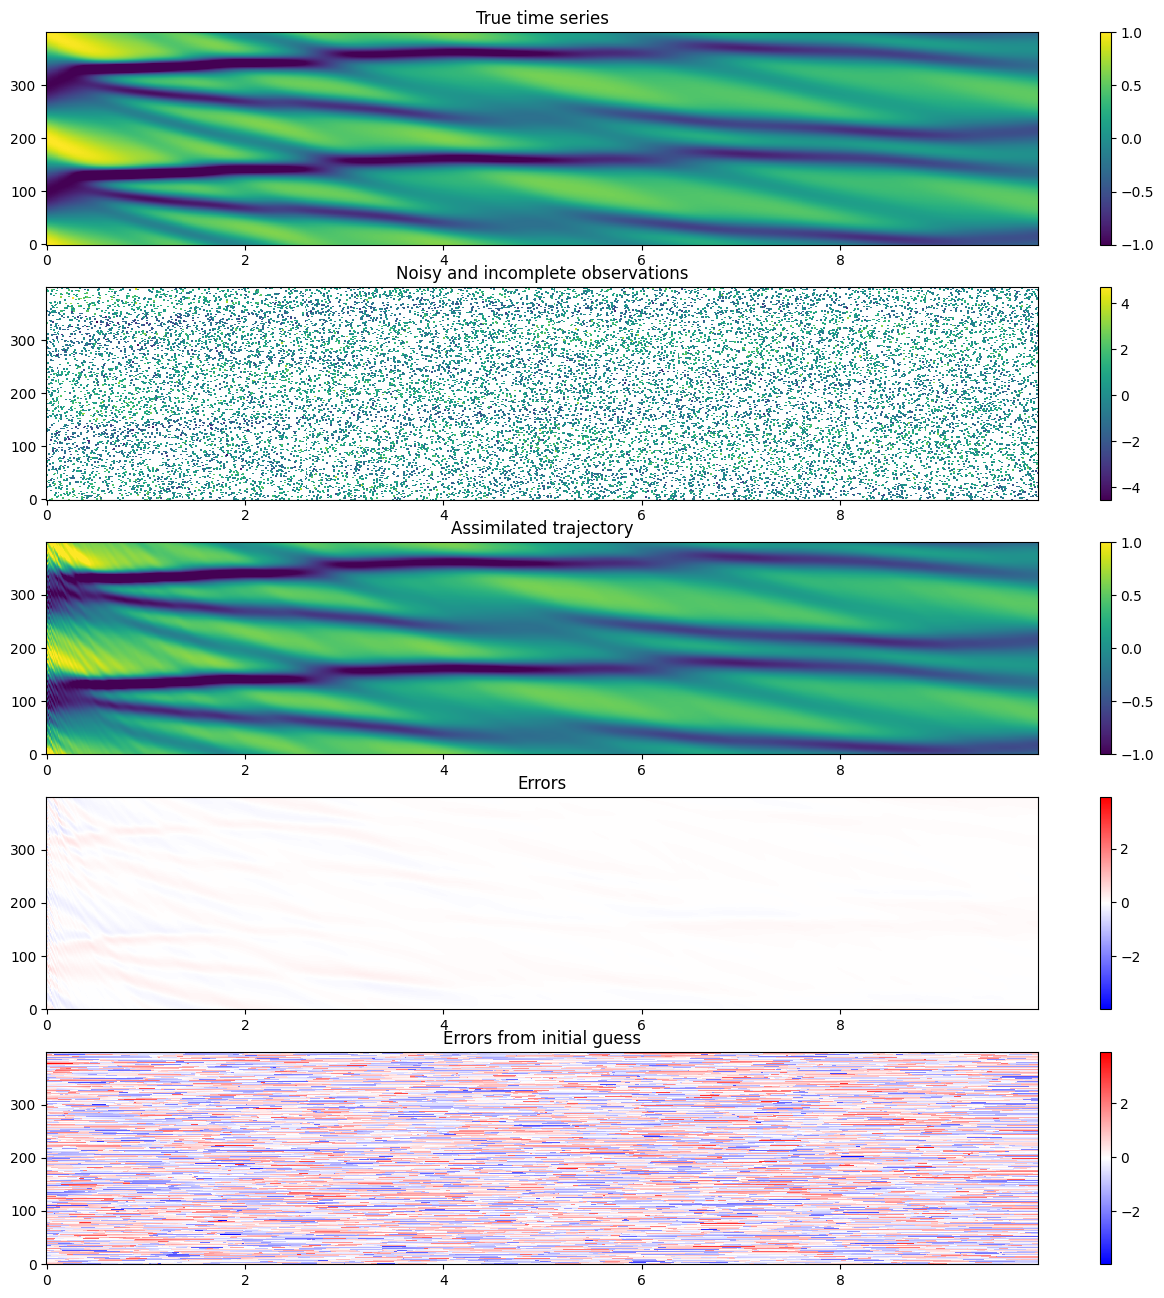

In [22]:
error = assimilated_states.fields['x'].detach() - true_series.fields['x']
error_2 = initialization.fields['x'].detach() - true_series.fields['x']
err_max = max(error.max(), error_2.max())
err_min = min(error.min(), error_2.min())
fig, ax = plt.subplots(5, 1, figsize=(16,16))
show_1dseqimg(true_series.fields['x'][0].T.detach().cpu().numpy(), dt=DT, ax=ax[0], title="True time series", vmin=-1, vmax=1)
show_1dseqimg(valid_obs.detach().cpu().numpy(), dt=DT, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg(assimilated_states.fields['x'].T.squeeze().detach().cpu().numpy(), dt=DT, ax=ax[2], vmin=-1, vmax=1, title="Assimilated trajectory")
show_1dseqimg(error.detach().squeeze().T.detach().cpu().numpy(), dt=DT, ax=ax[3], title="Errors", cmap="bwr", vmin=err_min, vmax=err_max)
show_1dseqimg(error_2.detach().squeeze().T.detach().cpu().numpy(), dt=DT, ax=ax[4], title="Errors from initial guess", cmap="bwr", vmin=err_min,  vmax=err_max)

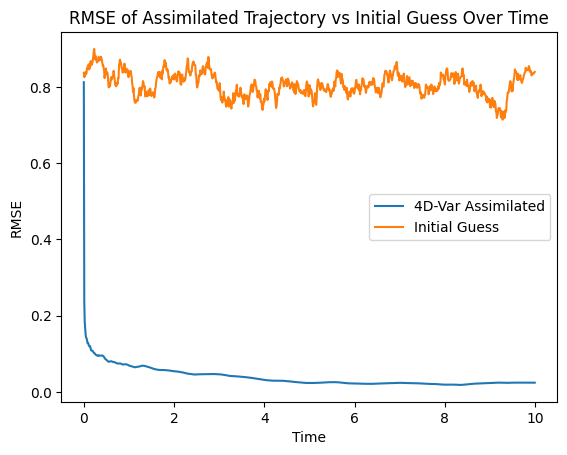

In [23]:
RMSE_over_time_assimilated = torch.mean(torch.sqrt((error.T ** 2)), dim=0)
RMSE_over_time_initial = torch.mean(torch.sqrt((error_2.T ** 2)), dim=0)

fig, ax = plt.subplots()
plt.plot(forecast_steps, RMSE_over_time_assimilated.squeeze().detach().cpu().numpy(), label='4D-Var Assimilated')
plt.plot(forecast_steps, RMSE_over_time_initial.squeeze().detach().cpu().numpy(), label='Initial Guess')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE')
plt.title("RMSE of Assimilated Trajectory vs Initial Guess Over Time")
plt.legend()
plt.show()